# 11-1절 연습 문제 풀이

변분 오토인코더(`FashionVAE`)를 다루는 [연습 문제 11-1] ~ [연습 문제 11-4]의 풀이다.

본문 예제(`11-01_example.ipynb`)의 데이터, 모델, 손실 함수, 학습 함수를 그대로 사용한다.


## 공통 준비

In [1]:

import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

viz.configure(save_grayscale=False)
common.set_korean_plot_env()

SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


In [2]:

# Fashion-MNIST 데이터셋(본문 예제와 동일)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
from torchvision import transforms

data_root = '../../download'
transform = transforms.Compose([transforms.ToTensor()])

train_set = FashionMNIST(root=data_root, train=True, download=True, transform=transform)
valid_set = FashionMNIST(root=data_root, train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 {len(train_set):,} / 검증 {len(valid_set):,}')
print('클래스:', train_set.classes)

훈련 60,000 / 검증 10,000
클래스: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:

# FashionVAE 클래스([코드 11-1], [코드 11-2])
class FashionVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(              # (1, 28, 28) -> (64, 7, 7)
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.flatten_dim = 64 * 7 * 7              # 3136
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_log_var = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_z_to_fmap = nn.Linear(latent_dim, self.flatten_dim)
        self.decoder = nn.Sequential(              # (64, 7, 7) -> (1, 28, 28)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1,
                               output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1,
                               output_padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z):
        h = self.fc_z_to_fmap(z)
        h = h.view(h.size(0), 64, 7, 7)
        return self.decoder(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var

In [4]:

# 손실 함수와 학습 루프([코드 11-3], [코드 11-4])
import copy

bce_loss = nn.BCELoss(reduction='sum')


def vae_loss(reconstructed, original, mu, log_var):
    bce = bce_loss(reconstructed, original) / original.size(0)
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / original.size(0)
    return bce + kl, bce, kl


def train_epoch(model, loader, optimizer, device):
    model.train()
    loss_sum = bce_sum = kl_sum = 0.0
    n = 0
    for images, _ in loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon, mu, log_var = model(images)
        loss, bce, kl = vae_loss(recon, images, mu, log_var)
        loss.backward()
        optimizer.step()
        b = images.size(0)
        loss_sum += loss.item() * b
        bce_sum += bce.item() * b
        kl_sum += kl.item() * b
        n += b
    return loss_sum / n, bce_sum / n, kl_sum / n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    loss_sum = bce_sum = kl_sum = 0.0
    n = 0
    for images, _ in loader:
        images = images.to(device)
        recon, mu, log_var = model(images)
        loss, bce, kl = vae_loss(recon, images, mu, log_var)
        b = images.size(0)
        loss_sum += loss.item() * b
        bce_sum += bce.item() * b
        kl_sum += kl.item() * b
        n += b
    return loss_sum / n, bce_sum / n, kl_sum / n


def train_loop(model, train_loader, valid_loader, optimizer,
               epochs, patience, device, name='', verbose_rows=8):
    if name:
        print(f'{name} 학습')
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.2f}', '{:.2f}'), target_rows=verbose_rows)
    bce_history, kl_history = [], []
    best_valid, best_state, best_epoch, counter = float('inf'), None, 0, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss, train_bce, train_kl = train_epoch(model, train_loader,
                                                      optimizer, device)
        valid_loss, valid_bce, valid_kl = evaluate(model, valid_loader, device)
        log.row(epoch, train_loss, valid_loss)
        bce_history.append(train_bce)
        kl_history.append(train_kl)
        if valid_loss < best_valid:
            best_valid, best_state, best_epoch, counter = (
                valid_loss, copy.deepcopy(model.state_dict()), epoch, 0)
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    log.summary(stopped='조기 종료' if stopped else None)
    vb, vbce, vkl = evaluate(model, valid_loader, device)
    print(f'{name}: 최적 에포크 {best_epoch}, 검증 손실 {vb:.2f} '
          f'(복원 {vbce:.2f} + KL {vkl:.2f})')
    return {'log': log, 'best_epoch': best_epoch, 'valid_loss': vb,
            'valid_bce': vbce, 'valid_kl': vkl,
            'train_bce': bce_history, 'train_kl': kl_history}


LR, EPOCHS, PATIENCE = 1e-3, 100, 5
results = {}

In [5]:

# 결과 시각화 도우미
import matplotlib.pyplot as plt


def show_images(tensors, titles=None, n_cols=8, title='', cmap='gray'):
    """(N, C, H, W) 텐서를 격자로 그린다."""
    imgs = tensors.detach().cpu().clamp(0, 1)
    n = imgs.size(0)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.35))
    axes = axes.reshape(-1) if n_rows * n_cols > 1 else [axes]
    for i, ax in enumerate(axes):
        ax.axis('off')
        if i < n:
            img = imgs[i]
            ax.imshow(img.squeeze(0) if img.size(0) == 1 else img.permute(1, 2, 0),
                      cmap=cmap if img.size(0) == 1 else None)
            if titles is not None and i < len(titles):
                ax.set_title(titles[i], fontsize=8)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def reconstruct(model, images):
    model.eval()
    recon, _, _ = model(images.to(device))
    return recon


@torch.no_grad()
def sample_images(model, n=16, latent_dim=None):
    model.eval()
    z = torch.randn(n, latent_dim or model.latent_dim).to(device)
    return model.decode(z)


# 이후 문제에서 공통으로 사용할 검증 샘플 8장
sample_batch, sample_labels = next(iter(valid_loader))
demo_images = sample_batch[:8]
print('검증 샘플 8장의 클래스:',
      [train_set.classes[i] for i in sample_labels[:8].tolist()])

검증 샘플 8장의 클래스: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Shirt']


## 연습 문제 11-1

In [6]:

# LATENT_DIM을 4, 16, 64로 바꿔 학습
for dim in (4, 16, 64):
    common.set_seed(SEED)
    m = FashionVAE(latent_dim=dim).to(device)
    opt = optim.Adam(m.parameters(), lr=LR)
    results[f'dim{dim}'] = train_loop(m, train_loader, valid_loader, opt,
                                      epochs=EPOCHS, patience=PATIENCE,
                                      device=device, name=f'LATENT_DIM {dim}')
    results[f'dim{dim}']['model'] = m
    print()

LATENT_DIM 4 학습


 에포크    훈련 손실    검증 손실     시간
  1/100       302.49       267.17     0:06


 13/100       249.27       249.18     1:22


 26/100       247.60       247.60     2:44


------------------------------------------
최적 27 에포크 · 검증 손실 247.40 · 전체 학습 시간 3:22 · (조기 종료)


...

 13/100       243.15       237.79     1:24


 26/100       240.98       236.29     2:49


 39/100       240.00       234.93     4:13


------------------------------------------
최적 45 에포크 · 검증 손실 234.76 · 전체 학습 시간 5:23 · (조기 종료)


LATENT_DIM 64: 최적 에포크 45, 검증 손실 234.76 (복원 217.42 + KL 17.34)



  LATENT_DIM      최적 에포크       검증 손실       복원 손실       KL 발산
------------------------------------------------------------
           4          27      247.40      237.82        9.58
          16          28      235.63      218.84       16.79
          64          45      234.76      217.42       17.34


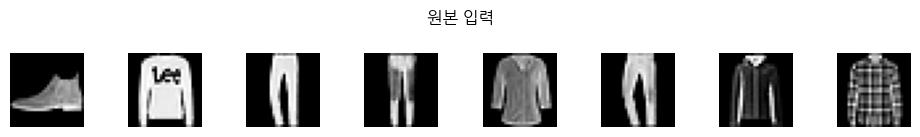

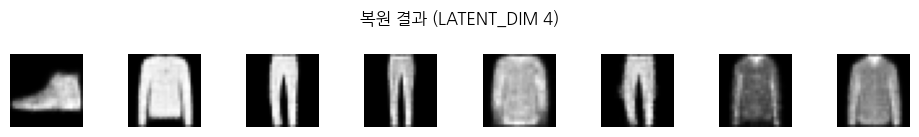

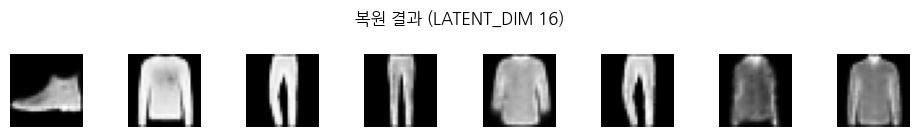

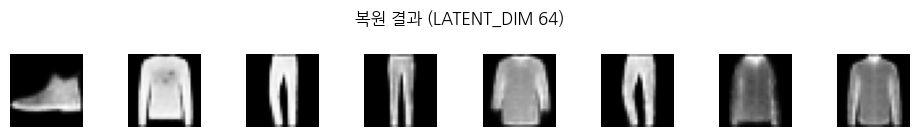

In [7]:

# 복원 품질과 생성 품질을 나눠서 비교
print(f'{"LATENT_DIM":>12}{"최적 에포크":>12}{"검증 손실":>12}{"복원 손실":>12}{"KL 발산":>12}')
print('-' * 60)
for dim in (4, 16, 64):
    r = results[f'dim{dim}']
    print(f'{dim:>12}{r["best_epoch"]:>12}{r["valid_loss"]:>12.2f}'
          f'{r["valid_bce"]:>12.2f}{r["valid_kl"]:>12.2f}')

# 복원 결과 비교(같은 입력 8장)
show_images(demo_images, title='원본 입력')
for dim in (4, 16, 64):
    show_images(reconstruct(results[f'dim{dim}']['model'], demo_images),
                title=f'복원 결과 (LATENT_DIM {dim})')

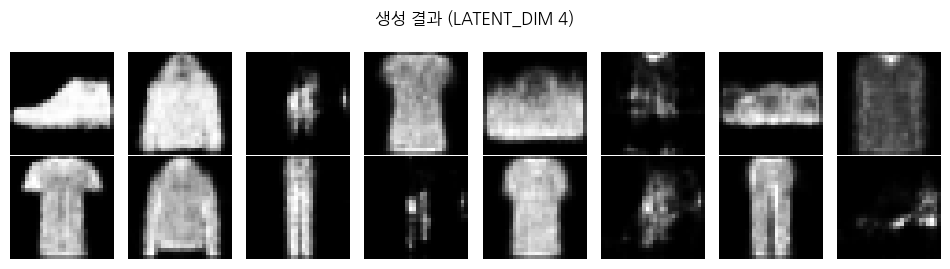

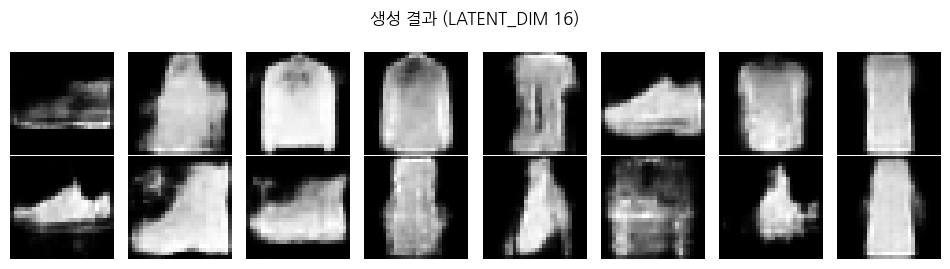

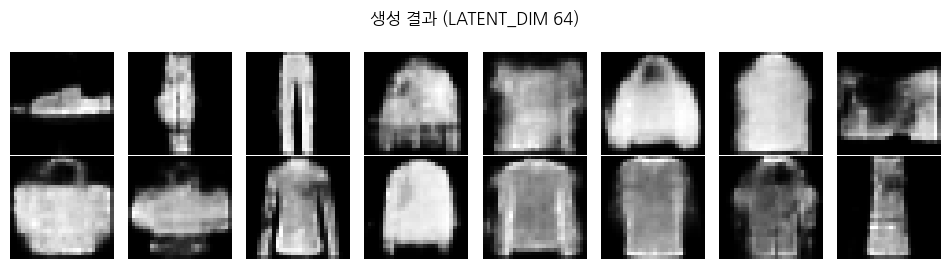

In [8]:

# 생성 품질 비교: 표준 정규 분포에서 뽑은 잠재 벡터로 생성
for dim in (4, 16, 64):
    common.set_seed(SEED)
    show_images(sample_images(results[f'dim{dim}']['model'], n=16),
                title=f'생성 결과 (LATENT_DIM {dim})')

In [9]:

# 생성 이미지가 '진짜 같은지'를 수치로: 잠재 공간의 사용률을 본다
#   각 잠재 차원의 mu 분산이 0에 가까우면 그 차원은 사실상 쓰이지 않는다(사후 붕괴)
@torch.no_grad()
def latent_usage(model, loader, max_batches=20):
    model.eval()
    mus = []
    for i, (images, _) in enumerate(loader):
        if i >= max_batches:
            break
        mu, _ = model.encode(images.to(device))
        mus.append(mu.cpu())
    mus = torch.cat(mus)
    var = mus.var(dim=0)
    return var


print(f'{"LATENT_DIM":>12}{"활성 차원 수":>14}{"평균 분산":>12}{"활성 비율":>12}')
print('-' * 52)
for dim in (4, 16, 64):
    var = latent_usage(results[f'dim{dim}']['model'], valid_loader)
    active = (var > 0.1).sum().item()        # 분산이 0.1을 넘는 차원을 '활성'으로 본다
    print(f'{dim:>12}{active:>14}{var.mean():>12.3f}{active / dim * 100:>11.1f}%')

  LATENT_DIM       활성 차원 수       평균 분산       활성 비율
----------------------------------------------------
           4             4       0.991      100.0%


          16            16       0.762      100.0%
          64            20       0.209       31.2%


### 풀이 해설 — 연습 문제 11-1

**이 문제는 복원 품질과 생성 품질을 나눠 봐야 한다.** 두 가지가 같은 방향으로 움직이지
않는 것이 요점이기 때문이다.

**복원 품질은 `LATENT_DIM`이 클수록 좋아진다.** 잠재 벡터가 담을 수 있는 정보량이
늘어나기 때문이다. 본문 p11이 "글자나 격자무늬 같은 세밀한 패턴은 흐릿하거나 복원되지
않는 한계"를 `LATENT_DIM=16`의 한계로 설명했는데, 64로 늘리면 그 패턴이 살아나는지
복원 결과에서 확인할 수 있다. 검증 손실의 **복원 손실 항**이 이를 수치로 보여 준다.

**생성 품질은 그렇지 않다.** 생성은 표준 정규 분포에서 잠재 벡터를 뽑아 디코더에
넣는 것인데, **잠재 공간이 커질수록 '그럴듯한 영역'의 비중이 줄어든다.** 4차원 공간에
비해 64차원 공간은 훨씬 넓고, 학습 데이터가 채우지 못한 빈틈이 상대적으로 많아진다.
차원이 커질수록 무작위로 뽑은 점이 학습된 영역 안에 떨어질 확률이 낮아지는 셈이다.

**반대로 `LATENT_DIM`이 너무 작으면 다른 문제가 생긴다.** 4차원으로는 열 가지 의류의
형태를 구분해 담기에 부족해, 복원도 생성도 뭉개진다. 서로 다른 클래스가 잠재 공간에서
겹치기 때문이다.

**잠재 공간 사용률이 이 균형을 수치로 드러낸다.** 마지막 셀에서 각 잠재 차원의 `mu`
분산을 재는데, 분산이 0에 가까운 차원은 **인코더가 사실상 쓰지 않는 차원**이다. KL
발산이 그 차원을 표준 정규 분포 쪽으로 눌러 버렸기 때문인데, 이 현상을 **사후 붕괴**
(posterior collapse)라고 부른다.

`LATENT_DIM`을 키워도 활성 차원 수가 그만큼 늘지 않는다면, **남는 차원은 KL 발산만
키울 뿐 복원에 기여하지 않는다.** 검증 손실의 KL 항이 차원 수에 따라 어떻게 변하는지
함께 보면 이 관계가 보인다.

**결론적으로 균형점은 데이터에 달려 있다.** Fashion-MNIST 28x28 흑백 이미지에는
본문이 고른 16이 무난하다. 다만 "가장 좋은 값"을 하나로 정하기보다, **무엇과 무엇을
맞바꾸고 있는지**를 설명할 수 있으면 이 문제의 목적은 달성된 것이다.


## 연습 문제 11-2

In [10]:

# Fashion-MNIST 분류 모델(간단한 CNN)
class FashionClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                   # (32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                   # (64, 7, 7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(64 * 7 * 7, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


common.set_seed(SEED)
clf = FashionClassifier().to(device)
clf_opt = optim.Adam(clf.parameters(), lr=1e-3)
clf_crit = nn.CrossEntropyLoss()

CLF_EPOCHS = 8
clf_log = common.EpochLogger(CLF_EPOCHS, target_rows=CLF_EPOCHS)
print('분류 모델 학습')
for epoch in range(1, CLF_EPOCHS + 1):
    clf.train()
    tot = n = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        clf_opt.zero_grad()
        loss = clf_crit(clf(images), labels)
        loss.backward()
        clf_opt.step()
        tot += loss.item() * images.size(0)
        n += images.size(0)
    clf.eval()
    vtot = vn = hit = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            out = clf(images)
            vtot += clf_crit(out, labels).item() * images.size(0)
            hit += (out.argmax(1) == labels).sum().item()
            vn += images.size(0)
    clf_log.row(epoch, tot / n, vtot / vn, hit / vn * 100)
clf_log.summary()

분류 모델 학습


에포크    훈련 손실    검증 손실    정확도(%)     시간
   1/8       0.4314       0.3329       87.62%     0:08


   2/8       0.3060       0.2814       90.12%     0:14


   3/8       0.2727       0.2771       90.46%     0:21


   4/8       0.2497       0.2706       90.15%     0:28


   5/8       0.2377       0.2455       91.02%     0:35


   6/8       0.2220       0.2380       91.75%     0:42


   7/8       0.2138       0.2579       90.56%     0:48


   8/8       0.2049       0.2447       91.26%     0:55
------------------------------------------------------
최적 6 에포크 · 검증 손실 0.2380 · 전체 학습 시간 0:55


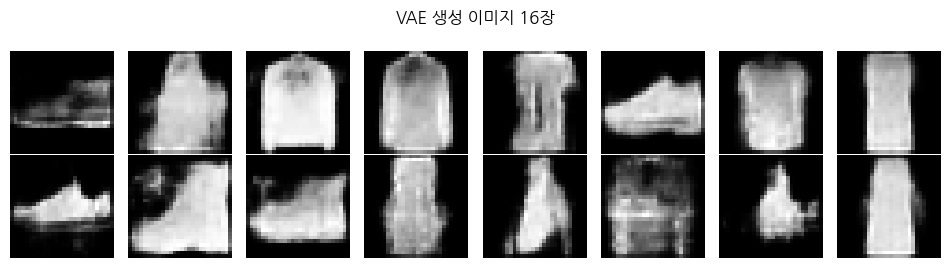

  번호          예측 클래스       신뢰도
--------------------------------
   0      Ankle boot     65.7%
   1             Bag     28.8%
   2            Coat     75.5%
   3           Shirt     38.9%
   4     T-shirt/top     78.6%
   5      Ankle boot     86.8%
   6     T-shirt/top     35.7%
   7     T-shirt/top     79.4%
   8         Sneaker    100.0%
   9      Ankle boot     92.3%
  10      Ankle boot     64.2%
  11           Dress     74.0%
  12      Ankle boot     65.6%
  13        Pullover     54.9%
  14         Sneaker     94.0%
  15     T-shirt/top     42.1%

클래스 분포: Counter({'Ankle boot': 5, 'T-shirt/top': 4, 'Sneaker': 2, 'Bag': 1, 'Coat': 1, 'Shirt': 1, 'Dress': 1, 'Pullover': 1})
평균 신뢰도: 67.3%


In [11]:

# VAE가 생성한 이미지를 분류해 본다([코드 11-5]와 같은 방식)
from collections import Counter

vae16 = results['dim16']['model']
common.set_seed(SEED)
generated = sample_images(vae16, n=16)
show_images(generated, title='VAE 생성 이미지 16장')

clf.eval()
with torch.no_grad():
    logits = clf(generated)
    probs = torch.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)

print(f'{"번호":>4}{"예측 클래스":>16}{"신뢰도":>10}')
print('-' * 32)
for i in range(16):
    print(f'{i:>4}{train_set.classes[pred[i]]:>16}{conf[i] * 100:>9.1f}%')
print()
print('클래스 분포:', Counter(train_set.classes[p] for p in pred.tolist()))
print(f'평균 신뢰도: {conf.mean() * 100:.1f}%')

In [12]:

# 생성 이미지와 진짜 이미지의 신뢰도 분포를 비교한다
@torch.no_grad()
def confidence_stats(images):
    clf.eval()
    probs = torch.softmax(clf(images.to(device)), dim=1)
    conf, pred = probs.max(dim=1)
    return conf.cpu(), pred.cpu()


common.set_seed(SEED)
gen_many = sample_images(vae16, n=1000)
real_many = torch.cat([b for b, _ in [next(iter(valid_loader))]])[:1000]

gen_conf, gen_pred = confidence_stats(gen_many)
real_conf, real_pred = confidence_stats(real_many)

print(f'{"구분":<12}{"샘플 수":>9}{"평균 신뢰도":>14}{"신뢰도 90% 이상":>18}')
print('-' * 56)
for name, conf in (('진짜 이미지', real_conf), ('VAE 생성 이미지', gen_conf)):
    print(f'{name:<12}{len(conf):>9}{conf.mean() * 100:>13.1f}%'
          f'{(conf > 0.9).float().mean() * 100:>17.1f}%')

print()
print('생성 이미지의 클래스 분포(1,000장)')
counts = Counter(gen_pred.tolist())
for idx in range(10):
    bar = '#' * round(counts.get(idx, 0) / 1000 * 100)
    print(f'  {train_set.classes[idx]:<14}{counts.get(idx, 0):>5}  {bar}')

구분               샘플 수        평균 신뢰도        신뢰도 90% 이상
--------------------------------------------------------
진짜 이미지            128         91.9%             77.3%
VAE 생성 이미지       1000         70.2%             26.2%

생성 이미지의 클래스 분포(1,000장)
  T-shirt/top     105  ##########
  Trouser          66  #######
  Pullover        179  ##################
  Dress           103  ##########
  Coat            127  #############
  Sandal           13  #
  Shirt            31  ###
  Sneaker         105  ##########
  Bag             122  ############
  Ankle boot      149  ###############


### 풀이 해설 — 연습 문제 11-2

**이 문제의 값어치는 "생성 모델을 다른 모델의 눈으로 평가한다"는 발상에 있다.**
본문은 생성 결과를 "형태와 구조를 보면 어느 클래스에 속하는지 충분히 알아볼 수 있다"고
눈으로 판단했는데, 분류기를 쓰면 그 판단을 수치로 바꿀 수 있다.

**세 가지를 확인할 수 있다.**

**하나, 생성 이미지가 어느 클래스로 분류되는가.** 대부분 실제 존재하는 클래스로
분류된다면 VAE가 데이터 분포를 제대로 익혔다는 뜻이다.

**둘, 분류 신뢰도가 진짜 이미지보다 낮은가.** 이쪽이 더 중요하다. VAE 생성 이미지는
본문이 말한 대로 "형태가 조금 애매하거나 흐릿"하다. 분류기가 진짜 이미지에는 99%
신뢰도를 주면서 생성 이미지에는 70~80%에 머문다면, **그 차이가 곧 생성 품질의 격차**다.
눈으로 "좀 흐릿하다"고 말하던 것을 숫자로 옮긴 셈이다.

**셋, 클래스 분포가 고른가.** 1,000장을 생성해 클래스별로 세어 보면 **모드 붕괴**
여부를 알 수 있다. 본문 p14 각주 6이 GAN의 문제로 소개한 현상인데, VAE도 완전히
자유롭지는 않다. 다만 VAE는 KL 발산이 잠재 공간을 표준 정규 분포로 끌어당기므로
GAN보다 이 문제에 강하다. 분포가 고르게 나온다면 그 강점이 확인된 것이다.

**다만 이 평가 방법에는 한계가 있다.** 분류기는 "이 이미지가 어느 클래스에 가까운가"만
답할 뿐 **"이미지로서 그럴듯한가"는 답하지 못한다.** 사람이 봐도 무엇인지 모를 흐릿한
얼룩에 분류기가 높은 신뢰도를 줄 수도 있다(10-2절에서 다룬 '분류하기 애매한 것과
어려운 것은 다르다'와 같은 이야기다).

실제 생성 모델 평가에는 이 아이디어를 발전시킨 **인셉션 점수(Inception Score)**나
**FID(Fréchet Inception Distance)** 같은 지표를 쓴다. 둘 다 사전 학습된 분류기의
출력을 활용한다는 점에서 이 문제와 같은 발상에서 출발한다.


## 연습 문제 11-3

In [13]:

# 다층 퍼셉트론 기반 VAE(7장 오토인코더와 같은 방식)
class FashionVAEMLP(nn.Module):
    def __init__(self, latent_dim=16, hidden_dim=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_dim = 28 * 28
        # 인코더: 평탄화한 이미지를 은닉 표현으로
        self.encoder = nn.Sequential(
            nn.Flatten(),                                  # (1, 28, 28) -> (784,)
            nn.Linear(self.input_dim, 512), nn.ReLU(),
            nn.Linear(512, hidden_dim), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)
        # 디코더: 잠재 벡터를 다시 784차원으로
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 512), nn.ReLU(),
            nn.Linear(512, self.input_dim), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var)
            return mu + torch.randn_like(std) * std
        return mu

    def decode(self, z):
        # 평탄화된 출력을 이미지 형태로 되돌린다(합성곱 버전과 인터페이스를 맞춤)
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var


common.set_seed(SEED)
model_mlp = FashionVAEMLP(latent_dim=16).to(device)
opt_mlp = optim.Adam(model_mlp.parameters(), lr=LR)
results['mlp'] = train_loop(model_mlp, train_loader, valid_loader, opt_mlp,
                            epochs=EPOCHS, patience=PATIENCE, device=device,
                            name='다층 퍼셉트론 VAE')
results['mlp']['model'] = model_mlp

다층 퍼셉트론 VAE 학습


 에포크    훈련 손실    검증 손실     시간
  1/100       287.79       255.55     0:05


 13/100       239.21       237.61     1:20


 26/100       236.82       235.96     2:40


------------------------------------------
최적 31 에포크 · 검증 손실 235.16 · 전체 학습 시간 3:41 · (조기 종료)


다층 퍼셉트론 VAE: 최적 에포크 31, 검증 손실 235.16 (복원 222.60 + KL 12.56)


모델                          파라미터      최적 에포크       검증 손실       복원 손실       KL 발산
--------------------------------------------------------------------------------
합성곱 VAE                  191,265          28      235.63      218.84       16.79
다층 퍼셉트론 VAE            1,079,600          31      235.16      222.60       12.56


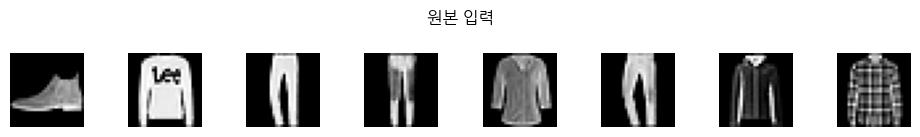

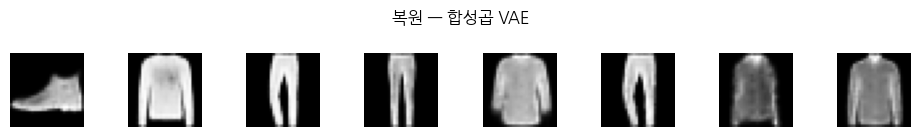

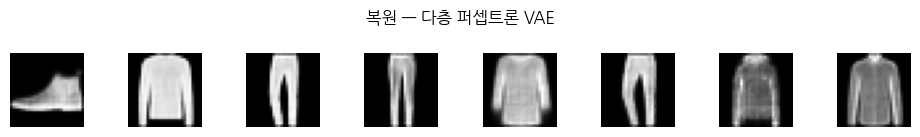

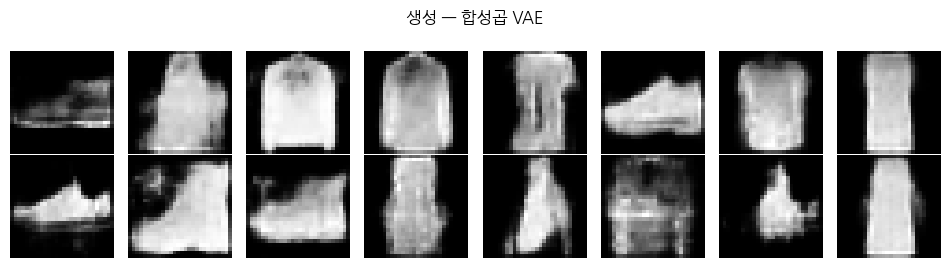

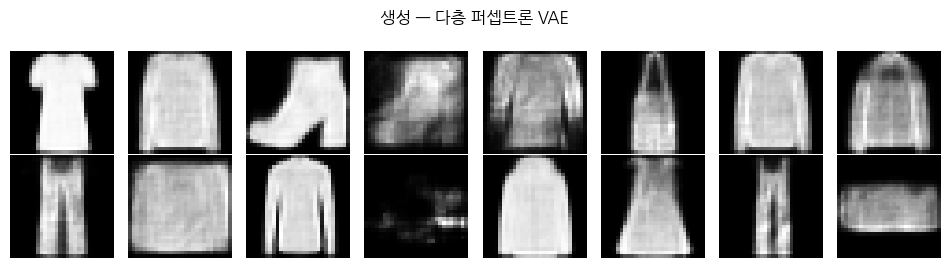

In [14]:

# 합성곱 VAE와 비교
conv = results['dim16']
mlp = results['mlp']

print(f'{"모델":<20}{"파라미터":>12}{"최적 에포크":>12}{"검증 손실":>12}'
      f'{"복원 손실":>12}{"KL 발산":>12}')
print('-' * 80)
for name, r, m in (('합성곱 VAE', conv, conv['model']), ('다층 퍼셉트론 VAE', mlp, model_mlp)):
    print(f'{name:<20}{sum(p.numel() for p in m.parameters()):>12,}'
          f'{r["best_epoch"]:>12}{r["valid_loss"]:>12.2f}'
          f'{r["valid_bce"]:>12.2f}{r["valid_kl"]:>12.2f}')

show_images(demo_images, title='원본 입력')
show_images(reconstruct(conv['model'], demo_images), title='복원 — 합성곱 VAE')
show_images(reconstruct(model_mlp, demo_images), title='복원 — 다층 퍼셉트론 VAE')

common.set_seed(SEED)
show_images(sample_images(conv['model'], n=16), title='생성 — 합성곱 VAE')
common.set_seed(SEED)
show_images(sample_images(model_mlp, n=16), title='생성 — 다층 퍼셉트론 VAE')

In [15]:

# 합성곱의 우위가 어디에서 오는지: 가장자리·윤곽의 복원 오차를 따로 잰다
@torch.no_grad()
def edge_error(model, loader, max_batches=10):
    """이미지의 경사(인접 픽셀 차이) 크기를 기준으로 오차를 나눠 집계한다."""
    model.eval()
    flat_err = edge_err = flat_n = edge_n = 0.0
    for i, (images, _) in enumerate(loader):
        if i >= max_batches:
            break
        images = images.to(device)
        recon, _, _ = model(images)
        err = (recon - images).abs()
        # 가로·세로 경사의 합으로 '윤곽다움'을 근사
        gx = torch.zeros_like(images)
        gy = torch.zeros_like(images)
        gx[..., :, 1:] = (images[..., :, 1:] - images[..., :, :-1]).abs()
        gy[..., 1:, :] = (images[..., 1:, :] - images[..., :-1, :]).abs()
        grad = gx + gy
        edge_mask = grad > 0.15                     # 윤곽 영역
        flat_mask = ~edge_mask
        edge_err += err[edge_mask].sum().item()
        edge_n += edge_mask.sum().item()
        flat_err += err[flat_mask].sum().item()
        flat_n += flat_mask.sum().item()
    return flat_err / flat_n, edge_err / edge_n


print(f'{"모델":<20}{"평탄 영역 오차":>16}{"윤곽 영역 오차":>16}{"윤곽/평탄 비":>14}')
print('-' * 68)
for name, m in (('합성곱 VAE', conv['model']), ('다층 퍼셉트론 VAE', model_mlp)):
    flat, edge = edge_error(m, valid_loader)
    print(f'{name:<20}{flat:>16.4f}{edge:>16.4f}{edge / flat:>14.2f}')

모델                          평탄 영역 오차        윤곽 영역 오차       윤곽/평탄 비
--------------------------------------------------------------------
합성곱 VAE                       0.0263          0.1313          4.99


다층 퍼셉트론 VAE                   0.0302          0.1371          4.54


### 풀이 해설 — 연습 문제 11-3

**구현에서 한 가지만 맞추면 된다. 인터페이스다.** 다층 퍼셉트론 인코더는 평탄화된
`(784,)` 벡터를 다루므로, `decode()`가 돌려주는 값도 `(784,)`다. 그대로 두면 손실
함수(`bce_loss(reconstructed, original)`)에서 `(B, 784)`와 `(B, 1, 28, 28)`을 비교하게
되어 형태가 맞지 않는다.

이 풀이는 `decode()` 끝에서 `.view(-1, 1, 28, 28)`로 이미지 형태를 되돌려, **본문의 손실
함수와 학습 루프를 한 줄도 고치지 않고 그대로 쓴다.** 모델을 바꿀 때 주변 코드까지
바꾸지 않도록 인터페이스를 맞추는 습관이 여기서 값을 한다.

**합성곱이 우위를 보이는 지점은 '어디를 잘 복원하는가'에 있다.**

다층 퍼셉트론은 784개 픽셀을 **순서 없는 벡터**로 다룬다. 이미지에서 이웃한 픽셀이
서로 관련 있다는 사실을 모르므로, 그 관계를 데이터에서 통째로 배워야 한다. 합성곱은
**이웃 픽셀만 보는 작은 커널**을 공유해 쓰므로, 그 관계가 구조에 미리 들어 있다.

그 차이가 가장 크게 드러나는 곳이 **윤곽**이다. 평탄한 배경은 어느 쪽이든 쉽게
복원하지만, 옷의 가장자리나 신발의 곡선처럼 **급격히 값이 변하는 자리**는 이웃 관계를
모르면 뭉개진다. 본문 p11이 "7장의 다층 퍼셉트론 기반 오토인코더에서는 가장자리가
흐릿하게 보였는데, 이번 모델은 전반적으로 더 선명하게 재현된다"고 한 것이 이 이야기다.

마지막 셀은 그 관찰을 수치로 옮긴 것이다. 인접 픽셀의 차이가 큰 자리를 **윤곽 영역**,
나머지를 **평탄 영역**으로 나눠 복원 오차를 따로 집계한다. 두 모델의 **평탄 영역 오차는
비슷한데 윤곽 영역 오차만 벌어진다면**, 합성곱의 이점이 정확히 어디에서 오는지 짚은
것이다.

**파라미터 수도 함께 볼 만하다.** 다층 퍼셉트론은 `784 x 512` 같은 큰 가중치 행렬이
필요해 파라미터가 훨씬 많다. 합성곱은 커널을 공유하므로 **적은 파라미터로 더 나은
복원**을 해낸다. 5장에서 합성곱 신경망을 도입할 때 든 근거가 생성 모델에서도 그대로
성립한다.


## 연습 문제 11-4 [도전 문제]

**데이터셋에 관한 주의 사항을 먼저 적어 둔다.**

지문이 예로 든 **CelebA는 `torchvision`으로 자동 내려받기가 사실상 어렵다.** 구글
드라이브에서 받아 오는데, `gdown` 패키지가 따로 필요하고 그마저도 일일 다운로드
할당량에 걸리는 일이 잦다. `LFWPeople`은 `torchvision` 최신 버전에서 **자동 다운로드가
아예 중단**되었다(수동으로 내려받아 배치해야 한다).

이 풀이는 **CelebA를 먼저 시도하고, 받을 수 없으면 CIFAR-10으로 대체**한다. CIFAR-10은
얼굴이 아니지만 **컬러 3채널 이미지**라는 점이 같아, 이 문제가 요구하는 세 가지
(채널 수 확장, 해상도 확장, 잠재 공간 보간)를 모두 확인할 수 있다. 얼굴 데이터셋을
직접 준비할 수 있다면 `face_root`만 바꿔 같은 코드를 쓰면 된다.

In [16]:

# 컬러 데이터셋 준비: CelebA를 시도하고 실패하면 CIFAR-10으로 대체
from torchvision.datasets import CIFAR10

IMG_SIZE = 32
color_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
])

color_name = None
try:
    from torchvision.datasets import CelebA
    color_train = CelebA(root=data_root, split='train', download=True,
                         transform=color_transform)
    color_valid = CelebA(root=data_root, split='valid', download=True,
                         transform=color_transform)
    color_name = 'CelebA(얼굴)'
except Exception as e:
    print(f'CelebA를 사용할 수 없어 CIFAR-10으로 대체한다: {type(e).__name__}')
    color_train = CIFAR10(root=data_root, train=True, download=True,
                          transform=color_transform)
    color_valid = CIFAR10(root=data_root, train=False, download=True,
                          transform=color_transform)
    color_name = 'CIFAR-10(컬러 대체)'

color_train_loader = DataLoader(color_train, batch_size=BATCH_SIZE, shuffle=True)
color_valid_loader = DataLoader(color_valid, batch_size=BATCH_SIZE, shuffle=False)
print(f'{color_name}: 훈련 {len(color_train):,} / 검증 {len(color_valid):,}')
print(f'샘플 형태: {tuple(color_train[0][0].shape)}')

CelebA를 사용할 수 없어 CIFAR-10으로 대체한다: RuntimeError


CIFAR-10(컬러 대체): 훈련 50,000 / 검증 10,000
샘플 형태: (3, 32, 32)


In [17]:

# 컬러 이미지용 VAE: 채널 수(3)와 해상도(32x32)에 맞춰 수정
class ColorVAE(nn.Module):
    def __init__(self, latent_dim=128, img_size=IMG_SIZE, channels=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.fmap = img_size // 8                              # 32 -> 4
        self.encoder = nn.Sequential(                          # (3, 32, 32)
            nn.Conv2d(channels, 32, 3, stride=2, padding=1), nn.ReLU(),   # (32, 16, 16)
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),         # (64, 8, 8)
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),        # (128, 4, 4)
        )
        self.flatten_dim = 128 * self.fmap * self.fmap
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_log_var = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_z_to_fmap = nn.Linear(latent_dim, self.flatten_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, channels, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var)
            return mu + torch.randn_like(std) * std
        return mu

    def decode(self, z):
        h = self.fc_z_to_fmap(z).view(-1, 128, self.fmap, self.fmap)
        return self.decoder(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        return self.decode(self.reparameterize(mu, log_var)), mu, log_var


common.set_seed(SEED)
color_vae = ColorVAE(latent_dim=128).to(device)
color_opt = optim.Adam(color_vae.parameters(), lr=LR)
results['color'] = train_loop(color_vae, color_train_loader, color_valid_loader,
                              color_opt, epochs=30, patience=5, device=device,
                              name=f'컬러 VAE({color_name})')

컬러 VAE(CIFAR-10(컬러 대체)) 학습


에포크    훈련 손실    검증 손실     시간
  1/30      1937.10      1853.51     0:09


  4/30      1830.23      1814.56     0:37


  8/30      1822.72      1807.81     1:11


 12/30      1820.16      1805.69     1:47


...

 20/30      1818.06      1804.81     2:56


 24/30      1817.49      1804.82     3:36


 28/30      1816.94      1802.87     4:20


 30/30      1816.74      1803.58     4:42
-----------------------------------------
최적 28 에포크 · 검증 손실 1802.87 · 전체 학습 시간 4:42


컬러 VAE(CIFAR-10(컬러 대체)): 최적 에포크 28, 검증 손실 1802.87 (복원 1757.43 + KL 45.45)


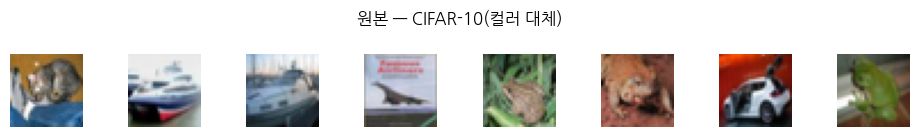

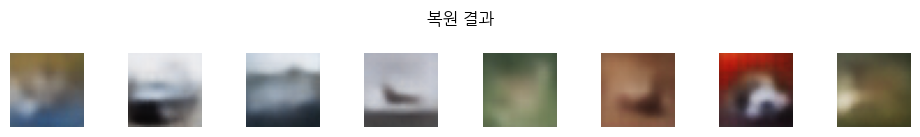

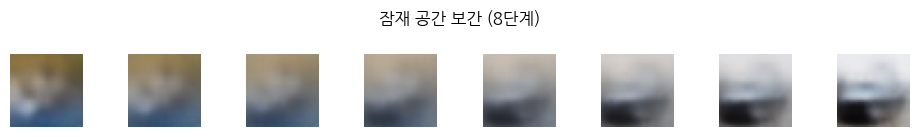

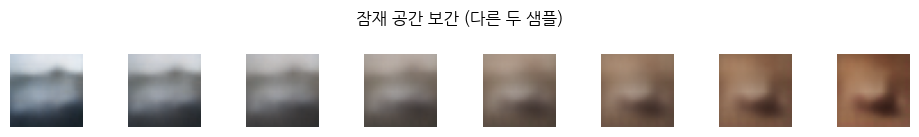

In [18]:

# 컬러 이미지 복원과 보간([코드 11-6]과 같은 방식)
color_batch, _ = next(iter(color_valid_loader))
show_images(color_batch[:8], title=f'원본 — {color_name}')
show_images(reconstruct(color_vae, color_batch[:8]), title='복원 결과')


@torch.no_grad()
def interpolate(model, img_a, img_b, steps=8):
    """두 이미지의 잠재 벡터 중심을 선형 보간해 중간 이미지를 만든다."""
    model.eval()
    mu_a, _ = model.encode(img_a.unsqueeze(0).to(device))
    mu_b, _ = model.encode(img_b.unsqueeze(0).to(device))
    alphas = torch.linspace(0, 1, steps).to(device)
    zs = torch.stack([(1 - a) * mu_a + a * mu_b for a in alphas]).squeeze(1)
    return model.decode(zs)


show_images(interpolate(color_vae, color_batch[0], color_batch[1]),
            n_cols=8, title='잠재 공간 보간 (8단계)')
show_images(interpolate(color_vae, color_batch[2], color_batch[5]),
            n_cols=8, title='잠재 공간 보간 (다른 두 샘플)')

### 풀이 해설 — 연습 문제 11-4

**흑백 28x28에서 컬러 32x32로 옮길 때 바꿔야 하는 것은 세 가지다.**

**하나, 입출력 채널 수.** 인코더 첫 합성곱의 입력 채널과 디코더 마지막 역합성곱의
출력 채널을 1에서 3으로 바꾼다. 나머지 계층은 그대로다.

**둘, 특징 지도 크기 계산.** `FashionVAE`는 `stride=2` 합성곱 두 개로 28을 7까지
줄였다(`28 → 14 → 7`). 32x32에 같은 구조를 쓰면 `32 → 16 → 8`이 되는데, 이 풀이는
합성곱을 하나 더 두어 `32 → 16 → 8 → 4`로 줄였다. **컬러 이미지는 담을 정보가
많으므로 인코더를 한 단계 더 깊게 가져가는 편이 낫다.** `self.fmap = img_size // 8`로
계산해 해상도를 바꿔도 따라오게 했다.

**셋, 잠재 차원.** 16에서 128로 크게 늘렸다. 채널이 3배가 되고 해상도도 커졌으므로
담아야 할 정보가 훨씬 많다. [연습 문제 11-1]에서 확인한 균형 문제가 여기서도 적용되는데,
**데이터가 복잡해지면 균형점도 함께 올라간다.**

**보간 코드는 한 줄도 바뀌지 않는다.** `encode()`로 `mu`를 구하고 선형 결합한 뒤
`decode()`로 돌려주는 절차가 채널 수와 무관하기 때문이다. 본문 p12가 "보간은 잠재
분포의 중심(mu)끼리 선형 결합해 이루어진다"고 한 그대로다.

**데이터셋에 관해 덧붙인다.** 얼굴 이미지로 보간하면 결과가 훨씬 인상적이다. 두 사람의
얼굴 사이를 잇는 중간 얼굴이 자연스럽게 이어지는 장면은 잠재 공간의 연속성을 가장
직관적으로 보여 준다. CIFAR-10처럼 **클래스가 뚜렷이 구분되는 데이터셋**에서는 중간
단계가 얼굴보다 어색하게 보이는데, 이는 구현의 문제가 아니라 데이터의 성격 때문이다.
얼굴은 모두 '눈 둘, 코 하나, 입 하나'라는 공통 구조를 공유하지만, 개구리와 트럭
사이에는 그런 공통 구조가 없다.

같은 이유로 **얼굴 데이터셋을 구할 수 있다면 꼭 시도해 보기를 권한다.** 코드는
`color_train`만 바꾸면 그대로 동작한다.
